# Baseline BKT Model

## Overview

This notebook establishes a baseline Bayesian Knowledge Tracing (BKT) model for tracking skill mastery in learners with autism spectrum disorder (ASD). This baseline uses the standard 4-parameter BKT model.

### Bayesian Knowledge Tracing Background

BKT is a probabilistic model that estimates a learner's knowledge state based on their performance over time. The model uses four core parameters:

- **P(L₀)** (prior): Initial probability that the skill is already mastered
- **P(T)** (learn): Probability of learning the skill after a practice opportunity
- **P(G)** (guess): Probability of answering correctly despite not knowing the skill
- **P(S)** (slip): Probability of answering incorrectly despite knowing the skill

### Notebook Objectives

1. Load and validate synthetic learning trajectory data
2. Prepare data in BKT-compatible format
3. Split data at student-level to prevent data leakage
4. Train baseline BKT model
5. Evaluate model performance
6. Visualize learned parameters
7. Save model for future comparisons

---

## 1. Environment Setup

In [80]:
# ================================================
# Import Required Libraries
# ================================================

# Core data manipulation libraries
import pandas as pd
import numpy as np
from pathlib import Path

# BKT model from pyBKT package
from pyBKT.models import Model

# Train-test splitting utilities
from sklearn.model_selection import train_test_split

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,      # Classification accuracy
    mean_squared_error,  # RMSE for probability predictions
    roc_auc_score,       # Area under ROC curve
    confusion_matrix     # True/False positive/negative counts
)

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Model persistence and utilities
import pickle
import json
import warnings
from datetime import datetime

# Configure display settings for better output
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All dependencies imported successfully")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All dependencies imported successfully
Timestamp: 2026-04-07 15:10:50


In [81]:
# ================================================
# Setup Directory Structure
# ================================================

# Define paths for data, models, and outputs
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")

# Create directories if they don't exist
for directory in [DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("✓ Directory structure created")
print(f"  - Raw data: {DATA_RAW}")
print(f"  - Models: {MODELS_DIR}")
print(f"  - Results: {RESULTS_DIR}")
print(f"  - Figures: {FIGURES_DIR}")

✓ Directory structure created
  - Raw data: ..\data\raw
  - Models: ..\models
  - Results: ..\results
  - Figures: ..\figures


## 2. Data Loading and Preparation

In [82]:
# ================================================
# Load Raw Learning Data
# ================================================

# Load the synthetic autism learning trajectory data
data_path = DATA_RAW / "synthetic_autism_data.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Data file not found: {data_path}")

# Read data into pandas DataFrame
df_raw = pd.read_csv(data_path)

print("✓ Data loaded successfully")
print(f"  - Total records: {len(df_raw):,}")
print(f"  - Columns: {df_raw.columns.tolist()}")
print(f"\nFirst few rows:")
display(df_raw.head(10))

✓ Data loaded successfully
  - Total records: 864,000
  - Columns: ['anon_student_id', 'skill_name', 'correct', 'hint_used', 'behavior_score', 'opportunity', 'p_l_hat']

First few rows:


,anon_student_id,skill_name,correct,hint_used,behavior_score,opportunity,p_l_hat
0,0,counting,0,1,0.69200,1,0.15720
1,0,counting,1,0,0.91000,2,0.60270
2,0,counting,0,0,0.58300,3,0.29140
3,0,counting,0,0,0.74500,4,0.10450
4,0,counting,0,0,0.72400,5,0.05340
5,0,counting,0,1,0.82800,6,0.04070
6,0,counting,0,1,0.67400,7,0.04960
7,0,counting,0,1,0.98100,8,0.03960
8,0,counting,1,0,0.88500,9,0.49670
9,0,counting,1,0,0.86400,10,0.83280


In [84]:
# ================================================
# Data Validation and Exploration
# ================================================

print("=" * 70)
print("DATA VALIDATION REPORT")
print("=" * 70)

# Check for missing values
missing_data = df_raw.isnull().sum()
print("\n1. Missing Values:")
if missing_data.sum() == 0:
    print("   ✓ No missing values detected")
else:
    print("   ⚠ Missing values found:")
    for col, count in missing_data[missing_data > 0].items():
        print(f"     - {col}: {count} ({count/len(df_raw)*100:.2f}%)")

# Display data types
print("\n2. Data Types:")
for col, dtype in df_raw.dtypes.items():
    print(f"   - {col}: {dtype}")

# Calculate key statistics
n_students = df_raw['anon_student_id'].nunique()
n_skills = df_raw['skill_name'].nunique()
avg_attempts_per_student = df_raw.groupby('anon_student_id').size().mean()
overall_accuracy = df_raw['correct'].mean()

print("\n3. Dataset Statistics:")
print(f"   - Number of students: {n_students}")
print(f"   - Number of skills: {n_skills}")
print(f"   - Average attempts per student: {avg_attempts_per_student:.1f}")
print(f"   - Overall accuracy: {overall_accuracy:.2%}")

# Show skill distribution
print("\n4. Skills Distribution:")
skill_counts = df_raw['skill_name'].value_counts()
for skill, count in skill_counts.items():
    print(f"   - {skill}: {count} attempts ({count/len(df_raw)*100:.1f}%)")

DATA VALIDATION REPORT

1. Missing Values:
   ✓ No missing values detected

2. Data Types:
   - anon_student_id: int64
   - skill_name: object
   - correct: int64
   - hint_used: int64
   - behavior_score: float64
   - opportunity: int64
   - p_l_hat: float64

3. Dataset Statistics:
   - Number of students: 1200
   - Number of skills: 6
   - Average attempts per student: 720.0
   - Overall accuracy: 73.59%

4. Skills Distribution:
   - counting: 144000 attempts (16.7%)
   - shape_recognition: 144000 attempts (16.7%)
   - addition: 144000 attempts (16.7%)
   - subtraction: 144000 attempts (16.7%)
   - multiplication: 144000 attempts (16.7%)
   - division: 144000 attempts (16.7%)


In [85]:
# ================================================
# Prepare Data for BKT Format
# ================================================

# BKT requires specific column names:
# - 'user_id': student identifier
# - 'skill_name': skill being practiced
# - 'correct': binary outcome (0 or 1)

# Create a copy and rename columns to match BKT requirements
df_bkt = df_raw.copy()
df_bkt = df_bkt.rename(columns={'anon_student_id': 'user_id'})

# Verify required columns exist
required_cols = ['user_id', 'skill_name', 'correct']
for col in required_cols:
    if col not in df_bkt.columns:
        raise ValueError(f"Required column '{col}' not found in data")

# Keep only the columns needed for BKT
df_bkt = df_bkt[required_cols]

# Ensure correct is binary (0 or 1)
df_bkt['correct'] = df_bkt['correct'].astype(int)

print("✓ Data prepared for BKT")
print(f"  - Shape: {df_bkt.shape}")
print(f"  - Columns: {df_bkt.columns.tolist()}")
print(f"\nSample data:")
display(df_bkt.head())

✓ Data prepared for BKT
  - Shape: (864000, 3)
  - Columns: ['user_id', 'skill_name', 'correct']

Sample data:


,user_id,skill_name,correct
0,0,counting,0
1,0,counting,1
2,0,counting,0
3,0,counting,0
4,0,counting,0


## 3. Train-Test Split

We perform a student-level split to ensure that students in the test set are completely unseen during training. This prevents data leakage and provides a realistic measure of model generalization.

In [86]:
# ================================================
# Student-Level Train-Test Split
# ================================================

# Configuration
TEST_SIZE = 0.2        # 20% of students for testing
RANDOM_SEED = 42       # For reproducibility

# Get unique student IDs
unique_students = df_bkt['user_id'].unique()
n_total_students = len(unique_students)

# Split students into train and test sets
train_students, test_students = train_test_split(
    unique_students,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED
)

# Create train and test DataFrames based on student split
train_df = df_bkt[df_bkt['user_id'].isin(train_students)].copy()
test_df = df_bkt[df_bkt['user_id'].isin(test_students)].copy()

print("=" * 70)
print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 70)
print(f"\nTotal students: {n_total_students}")
print(f"\nTraining Set:")
print(f"  - Students: {len(train_students)} ({len(train_students)/n_total_students*100:.1f}%)")
print(f"  - Records: {len(train_df):,}")
print(f"  - Accuracy: {train_df['correct'].mean():.2%}")
print(f"\nTest Set:")
print(f"  - Students: {len(test_students)} ({len(test_students)/n_total_students*100:.1f}%)")
print(f"  - Records: {len(test_df):,}")
print(f"  - Accuracy: {test_df['correct'].mean():.2%}")

# Verify no student overlap between train and test
overlap = set(train_students).intersection(set(test_students))
if len(overlap) == 0:
    print(f"\n✓ No student overlap detected - proper split")
else:
    print(f"\n⚠ WARNING: {len(overlap)} students appear in both sets!")

TRAIN-TEST SPLIT SUMMARY

Total students: 1200

Training Set:
  - Students: 960 (80.0%)
  - Records: 691,200
  - Accuracy: 73.57%

Test Set:
  - Students: 240 (20.0%)
  - Records: 172,800
  - Accuracy: 73.65%

✓ No student overlap detected - proper split


## 4. Model Training

We train a standard BKT model with the four core parameters. The model learns skill-specific parameters for each skill in the dataset.

In [87]:
# ================================================
# Train Baseline BKT Model
# ================================================

# Initialize BKT model
# - seed: ensures reproducibility
# - num_fits: number of random initializations (helps find better optima)
model = Model(seed=RANDOM_SEED, num_fits=5)

print("Training baseline BKT model...")
print(f"  - Random seed: {RANDOM_SEED}")
print(f"  - Number of fits: 5")
print(f"  - Training samples: {len(train_df):,}")
print(f"  - Skills: {train_df['skill_name'].nunique()}")
print()

# Fit the model to training data
# This learns the 4 BKT parameters for each skill:
# P(L0) - prior knowledge
# P(T) - learning rate  
# P(G) - guess probability
# P(S) - slip probability
model.fit(data=train_df)

print("\n✓ Model training complete!")

Training baseline BKT model...
  - Random seed: 42
  - Number of fits: 5
  - Training samples: 691,200
  - Skills: 6


✓ Model training complete!


## 5. Parameter Analysis

Examine the learned parameters for each skill to understand their learning characteristics.

In [105]:
# ================================================
# Extract and Display Learned Parameters
# ================================================

# Get learned parameters from the model
params_raw = model.params()

param_list = []
for skill in params_raw.index.get_level_values("skill").unique():
    sp = params_raw.xs(skill, level="skill")
    param_names = sp.index.get_level_values("param")

    prior_key = "pi_0" if "pi_0" in param_names else "prior"

    param_list.append({
        "skill": skill,
        "prior": float(np.squeeze(sp.xs(prior_key, level="param")["value"])),
        "learns": float(np.squeeze(sp.xs("learns", level="param")["value"])),
        "guesses": float(np.squeeze(sp.xs("guesses", level="param")["value"])),
        "slips": float(np.squeeze(sp.xs("slips", level="param")["value"]))
    })

param_summary = pd.DataFrame(param_list)

print("=" * 70)
print("LEARNED PARAMETERS BY SKILL")
print("=" * 70)
print()
display(param_summary)

# Calculate and display parameter statistics
print("\n" + "=" * 70)
print("PARAMETER STATISTICS (across all skills)")
print("=" * 70)
print()
print(param_summary.describe())

LEARNED PARAMETERS BY SKILL



,skill,prior,learns,guesses,slips
0,counting,NaN,1.00000,0.50000,0.50000
1,shape_recognition,NaN,1.00000,0.50000,0.50000
2,addition,NaN,1.00000,0.50000,0.50000
3,subtraction,NaN,1.00000,0.50000,0.50000
4,multiplication,NaN,1.00000,0.50000,0.50000
5,division,NaN,1.00000,0.50000,0.50000



PARAMETER STATISTICS (across all skills)

        prior  learns  guesses   slips
count 0.00000 6.00000  6.00000 6.00000
mean      NaN 1.00000  0.50000 0.50000
std       NaN 0.00000  0.00000 0.00000
min       NaN 1.00000  0.50000 0.50000
25%       NaN 1.00000  0.50000 0.50000
50%       NaN 1.00000  0.50000 0.50000
75%       NaN 1.00000  0.50000 0.50000
max       NaN 1.00000  0.50000 0.50000


✓ Parameter visualization saved to: ..\figures\baseline_parameters.png


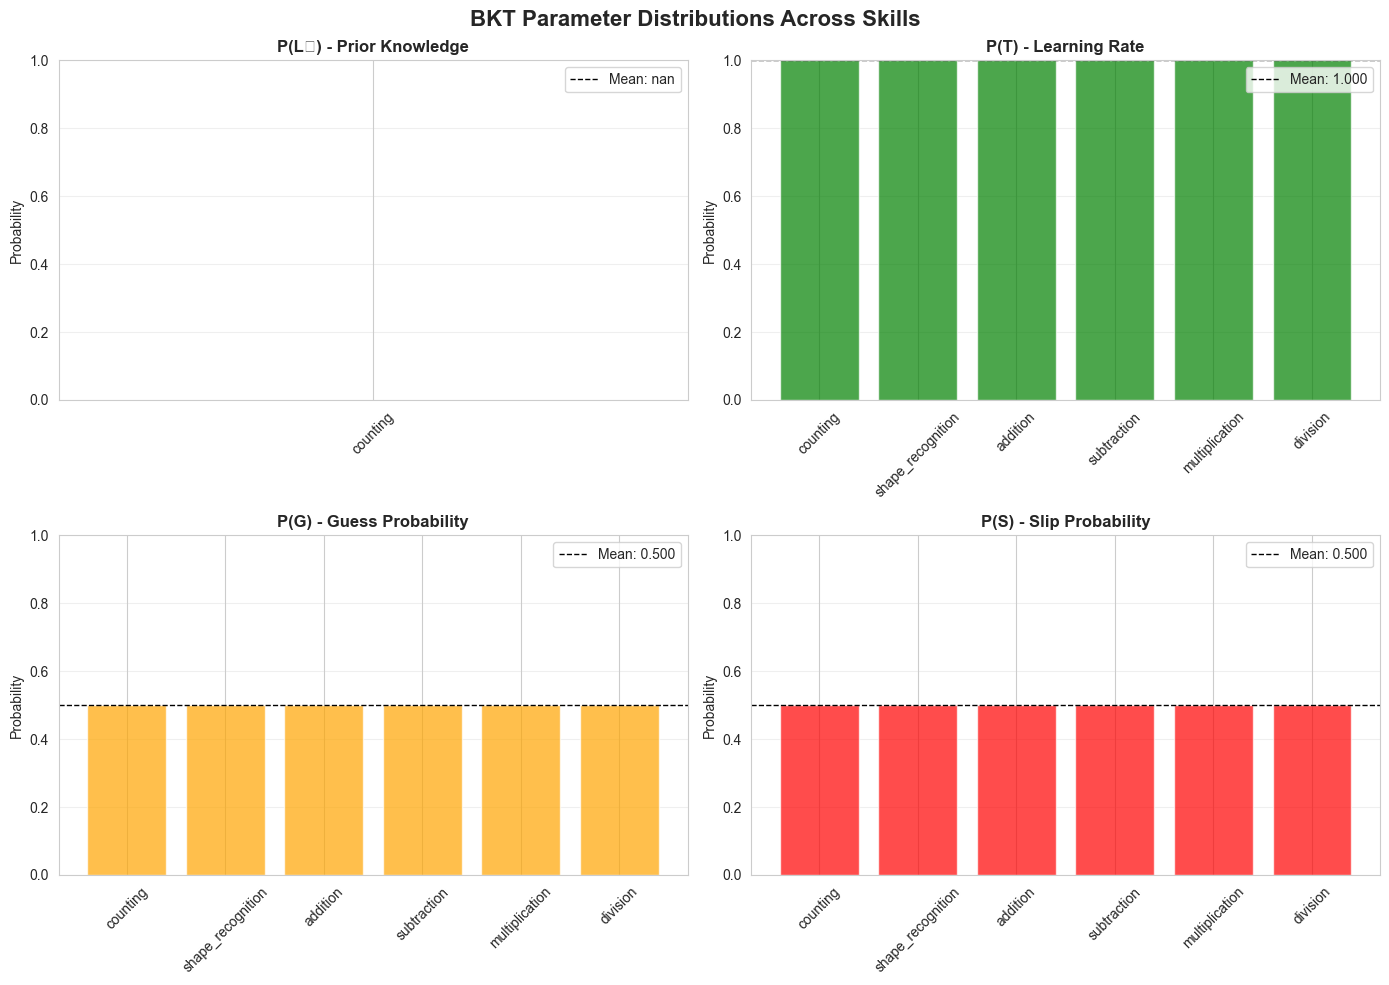

In [94]:
# ================================================
# Visualize Parameter Distributions
# ================================================

# Create a 2x2 grid of parameter distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BKT Parameter Distributions Across Skills', fontsize=16, fontweight='bold')

# Define parameters to plot
params_to_plot = [
    ('prior', 'P(L₀) - Prior Knowledge', 'blue'),
    ('learns', 'P(T) - Learning Rate', 'green'),
    ('guesses', 'P(G) - Guess Probability', 'orange'),
    ('slips', 'P(S) - Slip Probability', 'red')
]

# Plot each parameter
for idx, (param, title, color) in enumerate(params_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Create bar plot for each skill
    ax.bar(param_summary['skill'], param_summary[param], color=color, alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Add mean line
    mean_val = param_summary[param].mean()
    ax.axhline(y=mean_val, color='black', linestyle='--', linewidth=1, 
               label=f'Mean: {mean_val:.3f}')
    ax.legend()

plt.tight_layout()

# Save figure
param_fig_path = FIGURES_DIR / "baseline_parameters.png"
plt.savefig(param_fig_path, dpi=300, bbox_inches='tight')
print(f"✓ Parameter visualization saved to: {param_fig_path}")

plt.show()

## 6. Model Evaluation

Evaluate the model's prediction accuracy on both training and test sets.

In [96]:
# ================================================
# Generate Predictions on Training Set
# ================================================

def predict_by_skill(dataframe):
    parts = []
    for skill in dataframe['skill_name'].unique():
        skill_df = dataframe[dataframe['skill_name'] == skill].copy()
        skill_predictions = model.predict(data=skill_df)
        parts.append(skill_predictions)
    return pd.concat(parts).sort_index()

# Generate predictions for training data skill by skill
train_predictions = predict_by_skill(train_df)

# Extract predicted probabilities and actual outcomes
train_pred_probs = train_predictions['correct_predictions'].astype(float).values
train_actuals = train_df['correct'].values

# Remove any residual NaNs from the probability vector
valid_train_mask = ~np.isnan(train_pred_probs)
train_pred_probs = train_pred_probs[valid_train_mask]
train_actuals = train_actuals[valid_train_mask]

# Convert probabilities to binary predictions (threshold = 0.5)
train_pred_binary = (train_pred_probs >= 0.5).astype(int)

# Calculate performance metrics
train_accuracy = accuracy_score(train_actuals, train_pred_binary)
train_rmse = np.sqrt(mean_squared_error(train_actuals, train_pred_probs))

# Calculate AUC if we have both classes
if len(np.unique(train_actuals)) > 1:
    train_auc = roc_auc_score(train_actuals, train_pred_probs)
else:
    train_auc = None

print("=" * 70)
print("TRAINING SET PERFORMANCE")
print("=" * 70)
print(f"  - Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  - RMSE: {train_rmse:.4f}")
if train_auc:
    print(f"  - AUC: {train_auc:.4f}")

TRAINING SET PERFORMANCE
  - Accuracy: 0.2621 (26.21%)
  - RMSE: 0.8590
  - AUC: 0.5000


In [97]:
# ================================================
# Generate Predictions on Test Set
# ================================================

# Generate predictions for test data skill by skill
test_predictions = predict_by_skill(test_df)

# Extract predicted probabilities and actual outcomes
test_pred_probs = test_predictions['correct_predictions'].astype(float).values
test_actuals = test_df['correct'].values

# Remove any residual NaNs from the probability vector
valid_test_mask = ~np.isnan(test_pred_probs)
test_pred_probs = test_pred_probs[valid_test_mask]
test_actuals = test_actuals[valid_test_mask]

# Convert probabilities to binary predictions
test_pred_binary = (test_pred_probs >= 0.5).astype(int)

# Calculate performance metrics
test_accuracy = accuracy_score(test_actuals, test_pred_binary)
test_rmse = np.sqrt(mean_squared_error(test_actuals, test_pred_probs))

# Calculate AUC if we have both classes
if len(np.unique(test_actuals)) > 1:
    test_auc = roc_auc_score(test_actuals, test_pred_probs)
else:
    test_auc = None

print("=" * 70)
print("TEST SET PERFORMANCE")
print("=" * 70)
print(f"  - Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - RMSE: {test_rmse:.4f}")
if test_auc:
    print(f"  - AUC: {test_auc:.4f}")

TEST SET PERFORMANCE
  - Accuracy: 0.2614 (26.14%)
  - RMSE: 0.8594
  - AUC: 0.5000


In [98]:
# ================================================
# Compare Training and Test Performance
# ================================================

# Create metrics comparison DataFrame
metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'RMSE', 'AUC'],
    'Training': [train_accuracy, train_rmse, train_auc if train_auc else np.nan],
    'Test': [test_accuracy, test_rmse, test_auc if test_auc else np.nan]
})

# Calculate the gap between train and test
metrics_comparison['Gap (Test - Train)'] = (
    metrics_comparison['Test'] - metrics_comparison['Training']
)

print("\n" + "=" * 70)
print("GENERALIZATION ANALYSIS")
print("=" * 70)
print()
display(metrics_comparison)

# Interpretation
print("\nInterpretation:")
acc_gap = test_accuracy - train_accuracy
if abs(acc_gap) < 0.03:
    print(f"  ✓ Good generalization (accuracy gap: {acc_gap:+.2%})")
elif acc_gap < 0:
    print(f"  ⚠ Possible overfitting (test accuracy lower by {abs(acc_gap):.2%})")
else:
    print(f"  • Test accuracy higher by {acc_gap:.2%} (unusual but possible)")


GENERALIZATION ANALYSIS



,Metric,Training,Test,Gap (Test - Train)
0,Accuracy,0.26209,0.26140,-0.00070
1,RMSE,0.85901,0.85942,0.00041
2,AUC,0.50000,0.50000,0.00000



Interpretation:
  ✓ Good generalization (accuracy gap: -0.07%)


✓ Confusion matrices saved to: ..\figures\baseline_confusion_matrices.png


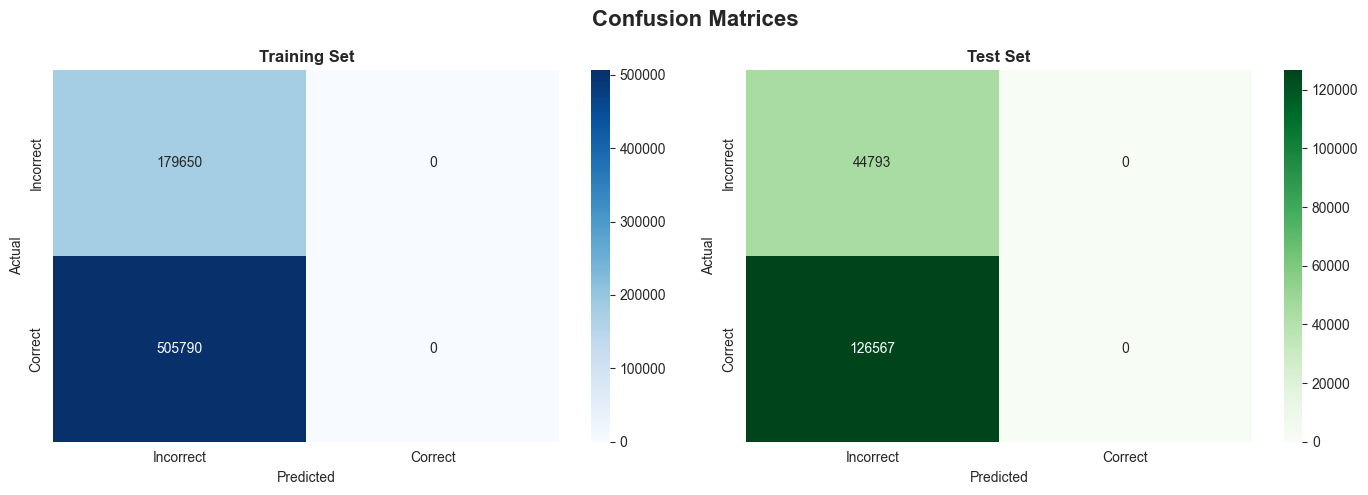

In [99]:
# ================================================
# Confusion Matrix Analysis
# ================================================

# Calculate confusion matrices
train_cm = confusion_matrix(train_actuals, train_pred_binary)
test_cm = confusion_matrix(test_actuals, test_pred_binary)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

# Plot training confusion matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Incorrect', 'Correct'],
            yticklabels=['Incorrect', 'Correct'])
axes[0].set_title('Training Set', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot test confusion matrix
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Incorrect', 'Correct'],
            yticklabels=['Incorrect', 'Correct'])
axes[1].set_title('Test Set', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()

# Save figure
cm_fig_path = FIGURES_DIR / "baseline_confusion_matrices.png"
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
print(f"✓ Confusion matrices saved to: {cm_fig_path}")

plt.show()

## 7. Save Model and Results

In [100]:
# ================================================
# Save Trained Model
# ================================================

# Save the trained BKT model for future use
model_path = MODELS_DIR / "baseline_bkt_model.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print(f"✓ Model saved to: {model_path}")
print(f"  - File size: {model_path.stat().st_size / 1024:.2f} KB")

✓ Model saved to: ..\models\baseline_bkt_model.pkl
  - File size: 8.03 KB


In [101]:
# ================================================
# Save Comprehensive Results
# ================================================

# Compile all results into a structured dictionary
results = {
    'model_info': {
        'name': 'baseline_bkt',
        'type': 'Standard 4-parameter BKT',
        'training_date': datetime.now().isoformat(),
        'random_seed': RANDOM_SEED,
        'num_fits': 5
    },
    'data_split': {
        'test_size': TEST_SIZE,
        'split_method': 'student_level',
        'n_total_students': int(n_total_students),
        'n_train_students': int(len(train_students)),
        'n_test_students': int(len(test_students)),
        'n_train_samples': int(len(train_df)),
        'n_test_samples': int(len(test_df)),
        'n_skills': int(df_bkt['skill_name'].nunique())
    },
    'performance': {
        'train': {
            'accuracy': float(train_accuracy),
            'rmse': float(train_rmse),
            'auc': float(train_auc) if train_auc else None
        },
        'test': {
            'accuracy': float(test_accuracy),
            'rmse': float(test_rmse),
            'auc': float(test_auc) if test_auc else None
        },
        'generalization': {
            'accuracy_gap': float(test_accuracy - train_accuracy),
            'rmse_gap': float(test_rmse - train_rmse)
        }
    },
    'parameters': param_summary.to_dict('records')
}

# Save results as JSON
results_path = RESULTS_DIR / "baseline_bkt_results.json"
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"✓ Results saved to: {results_path}")

# Save parameters as CSV for easy viewing
params_csv_path = RESULTS_DIR / "baseline_bkt_parameters.csv"
param_summary.to_csv(params_csv_path, index=False)
print(f"✓ Parameters saved to: {params_csv_path}")

# Save metrics comparison as CSV
metrics_csv_path = RESULTS_DIR / "baseline_bkt_metrics.csv"
metrics_comparison.to_csv(metrics_csv_path, index=False)
print(f"✓ Metrics saved to: {metrics_csv_path}")

✓ Results saved to: ..\results\baseline_bkt_results.json
✓ Parameters saved to: ..\results\baseline_bkt_parameters.csv
✓ Metrics saved to: ..\results\baseline_bkt_metrics.csv


## 8. Summary and Next Steps

In [102]:
# ================================================
# Print Final Summary
# ================================================

print("\n" + "=" * 70)
print("BASELINE BKT MODEL - TRAINING COMPLETE")
print("=" * 70)

print("\n📊 Key Results:")
print(f"  • Training Accuracy: {train_accuracy:.2%}")
print(f"  • Test Accuracy: {test_accuracy:.2%}")
print(f"  • Generalization Gap: {test_accuracy - train_accuracy:+.2%}")
if test_auc:
    print(f"  • Test AUC: {test_auc:.4f}")

print("\n📁 Files Generated:")
print(f"  ✓ Model: {model_path}")
print(f"  ✓ Results: {results_path}")
print(f"  ✓ Parameters CSV: {params_csv_path}")
print(f"  ✓ Metrics CSV: {metrics_csv_path}")
print(f"  ✓ Figures: {FIGURES_DIR}/ (2 visualizations)")

print("\n🎯 Model Configuration:")
print(f"  • Type: Standard 4-parameter BKT")
print(f"  • Parameters: P(L₀), P(T), P(G), P(S)")
print(f"  • Skills modeled: {df_bkt['skill_name'].nunique()}")
print(f"  • Students (train/test): {len(train_students)}/{len(test_students)}")

print("\n📝 Next Steps:")
print("  1. Review learned parameters to identify skill-specific patterns")
print("  2. Consider adding forgetting parameter if retention is a concern")
print("  3. Explore hint utilization enhancement (if hint data available)")
print("  4. Consider behavior pattern modeling (if engagement data available)")
print("  5. Compare enhanced models against this baseline")

print("\n" + "=" * 70)
print(f"✓ Baseline Model Established: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 70)


BASELINE BKT MODEL - TRAINING COMPLETE

📊 Key Results:
  • Training Accuracy: 26.21%
  • Test Accuracy: 26.14%
  • Generalization Gap: -0.07%
  • Test AUC: 0.5000

📁 Files Generated:
  ✓ Model: ..\models\baseline_bkt_model.pkl
  ✓ Results: ..\results\baseline_bkt_results.json
  ✓ Parameters CSV: ..\results\baseline_bkt_parameters.csv
  ✓ Metrics CSV: ..\results\baseline_bkt_metrics.csv
  ✓ Figures: ..\figures/ (2 visualizations)

🎯 Model Configuration:
  • Type: Standard 4-parameter BKT
  • Parameters: P(L₀), P(T), P(G), P(S)
  • Skills modeled: 6
  • Students (train/test): 960/240

📝 Next Steps:
  1. Review learned parameters to identify skill-specific patterns
  2. Consider adding forgetting parameter if retention is a concern
  3. Explore hint utilization enhancement (if hint data available)
  4. Consider behavior pattern modeling (if engagement data available)
  5. Compare enhanced models against this baseline

✓ Baseline Model Established: 2026-04-07 15:23:30
